# ERM untied exp

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import glob
import os

# run_id = "20251212_2158" # rho = 1 
# run_id = "20251213_1005" # rho = 0.75
run_id = "20251213_1804" # rho = 1.5

## 1. experiment config

In [2]:
run_dir = f"../results/run_{run_id}/"
config_path = f"../results/run_{run_id}/config.csv"
base_path = f"../results/run_{run_id}/summary.csv"

# --- Read the CSV file ---
config = pd.read_csv(config_path)
print(f"⚙️ Config loaded ({len(config)} rows) from {config_path}")

# --- Quick preview ---
display(config)

plot_path = f"../results/run_{run_id}/plots/"
os.makedirs(plot_path, exist_ok=True)

⚙️ Config loaded (10 rows) from ../results/run_20251213_1804/config.csv


,alpha,D,L,rho,rho_star,beta,lam,Delta_in,samples,T,learning_rate,norm_init,tol,N_test,base_dir
0,0.010000,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
1,0.080714,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
2,0.151429,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
3,0.222143,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
4,0.292857,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
5,0.929286,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
6,1.000000,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
7,0.363571,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
8,0.858571,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...
9,0.434286,100,2,1.5,0.5,1.0,0.00001,0.5,16,10000,0.1,1.0,0.000001,2000,/home/peucelle/tpiv-simulations/results/run_20...


## 2. Metric as function of $\alpha$ for different $\rho$

✅ Summary loaded (70 rows) from ../results/run_20251213_1804/summary.csv


,alpha,alpha_idx,lam,rho,MSE_mean,MSE_std,label_err_mean,label_err_std,label_err_mean_noise,label_err_std_noise,train_data_mean,train_reg_mean,train_total_mean
0,0.01,0,0.1000,1.5,0.009710,2.981520e-11,0.262687,0.004197,0.319963,0.004411,0.003189,4.528154e-09,0.003189
1,0.01,0,0.0100,1.5,0.009502,4.169300e-05,0.266720,0.006229,0.325981,0.006422,0.000209,8.646648e-04,0.001073
2,0.01,0,0.0050,1.5,0.010408,5.132060e-05,0.285136,0.005434,0.341361,0.006773,0.000076,5.303331e-04,0.000607
3,0.01,0,0.0010,1.5,0.010918,6.847775e-05,0.297429,0.007122,0.352085,0.005975,0.000007,1.377156e-04,0.000145
4,0.01,0,0.0005,1.5,0.010088,7.554757e-05,0.289071,0.005983,0.345826,0.005554,0.000002,6.888471e-05,0.000071


✅ Saved plot: ../results/run_20251213_1804/plots/MSE_vs_alpha_20251213_1804.png


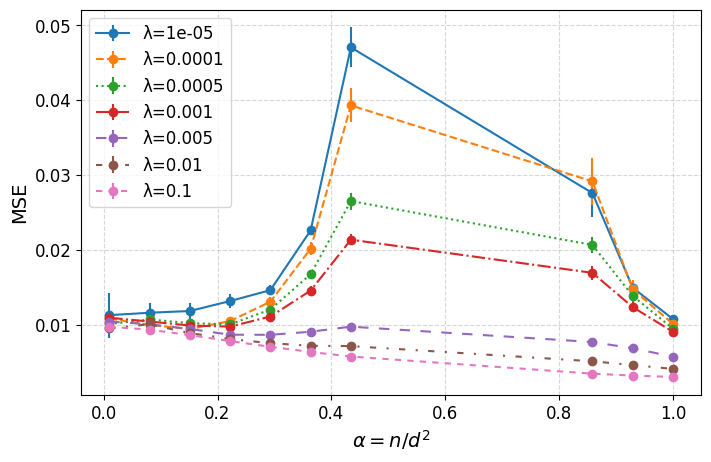

✅ Saved plot: ../results/run_20251213_1804/plots/LabelError_vs_alpha_20251213_1804.png


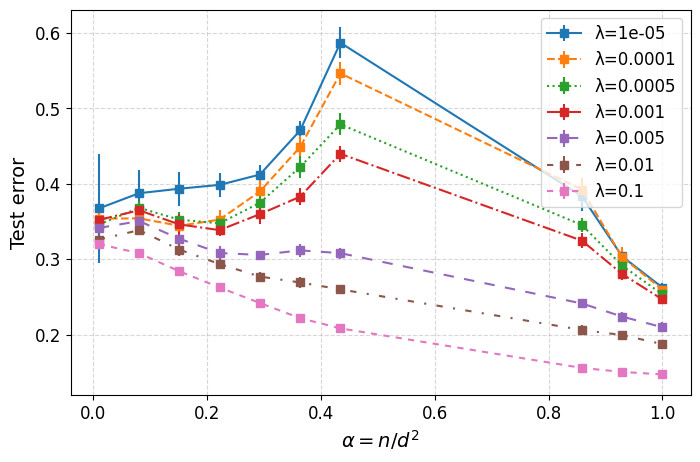

✅ Saved plot: ../results/run_20251213_1804/plots/TrainData_vs_alpha_20251213_1804.png


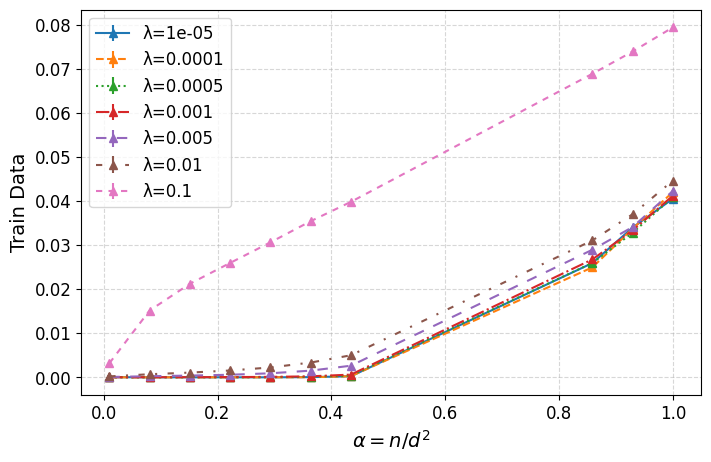

In [3]:
# --- Read the CSV file ---
df = pd.read_csv(base_path)
print(f"✅ Summary loaded ({len(df)} rows) from {base_path}")

# --- Quick preview ---
display(df.head())

linestyles = [
    "-",
    "--",
    ":",
    "-.",
    (0, (5, 5)),
    (0, (3, 5, 1, 5)),
    (0, (3, 3))
]

alpha_ticks = np.linspace(df["alpha"].min(), df["alpha"].max(), 3)  # 5 ticks seulement

# --- Plot MSE vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for i, lam in enumerate(sorted(df["lam"].unique())):
    subset = df[df["lam"] == lam].sort_values("alpha")  # Sort by alpha
    plt.errorbar(subset["alpha"], subset["MSE_mean"], yerr=subset.get("MSE_std", 0),
                 marker='o', capsize=0, label=f"λ={lam}", ls=linestyles[i % len(linestyles)])
# --- Réduire le nombre de ticks ---
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel(r"$\alpha = n / d^2$", fontsize=14)
plt.ylabel("MSE", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
mse_path = os.path.join(plot_path, f"MSE_vs_alpha_{run_id}.png")
plt.savefig(mse_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved plot: {mse_path}")
plt.show()

# --- Plot Label Error vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for i, lam in enumerate(sorted(df["lam"].unique())):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["label_err_mean_noise"], yerr=subset.get("label_err_std_noise", 0),
                 marker='s', capsize=0, label=f"λ={lam}", ls=linestyles[i % len(linestyles)])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()
plt.xlabel(r"$\alpha = n / d^2$", fontsize=14)
plt.ylabel("Test error", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
label_err_path = os.path.join(plot_path, f"LabelError_vs_alpha_{run_id}.png")
plt.savefig(label_err_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved plot: {label_err_path}")
plt.show()

# --- Plot Train Data vs alpha with error bars (grouped by lambda) ---
plt.figure(figsize=(8, 5))
for i, lam in enumerate(sorted(df["lam"].unique())):
    subset = df[df["lam"] == lam].sort_values("alpha")
    plt.errorbar(subset["alpha"], subset["train_data_mean"], yerr=subset.get("train_data_std", 0),
                 marker='^', capsize=0, label=f"λ={lam}", ls=linestyles[i % len(linestyles)])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
ax = plt.gca()
plt.xlabel(r"$\alpha = n / d^2$", fontsize=14)
plt.ylabel("Train Data", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
train_data_path = os.path.join(plot_path, f"TrainData_vs_alpha_{run_id}.png")
plt.savefig(train_data_path, dpi=300, bbox_inches='tight')
print(f"✅ Saved plot: {train_data_path}")
plt.show()

## 3. Eigenvalue distributions per $\rho$

Found 10 W_Q files and 10 W_K files.

Comparing Q vs K for W_Q_runs_0.pkl


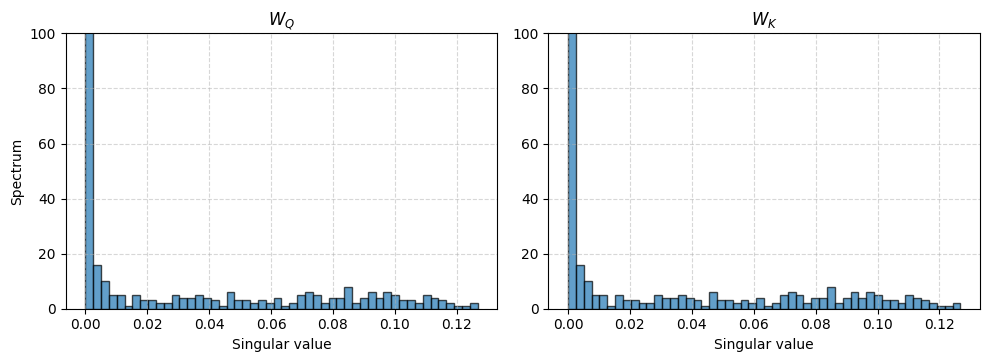


Comparing Q vs K for W_Q_runs_1.pkl


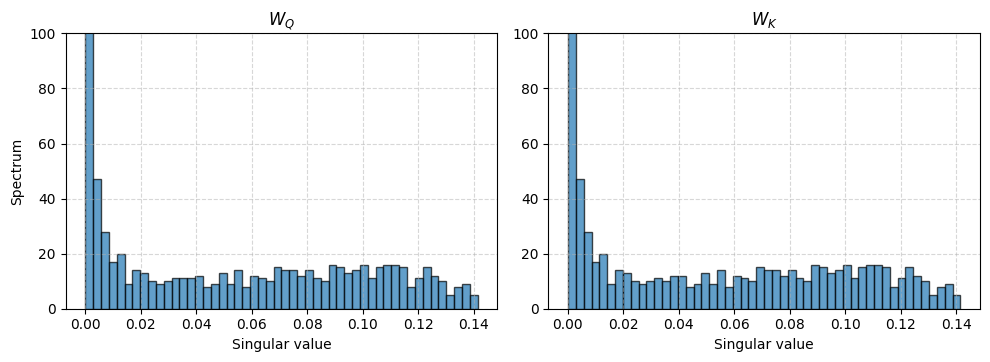


Comparing Q vs K for W_Q_runs_12.pkl


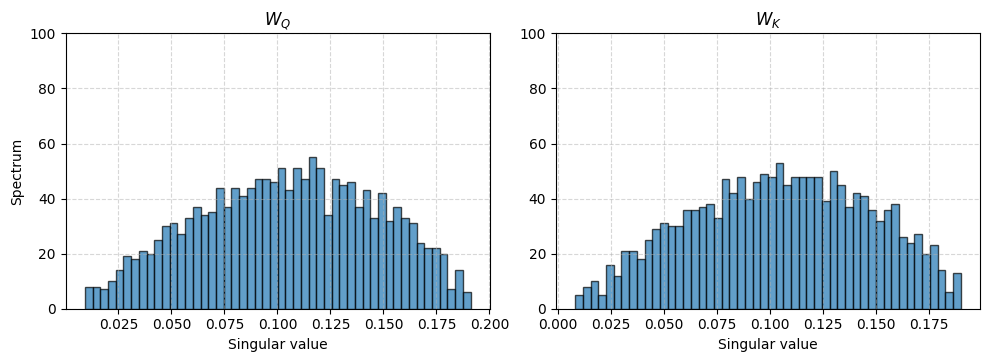


Comparing Q vs K for W_Q_runs_13.pkl


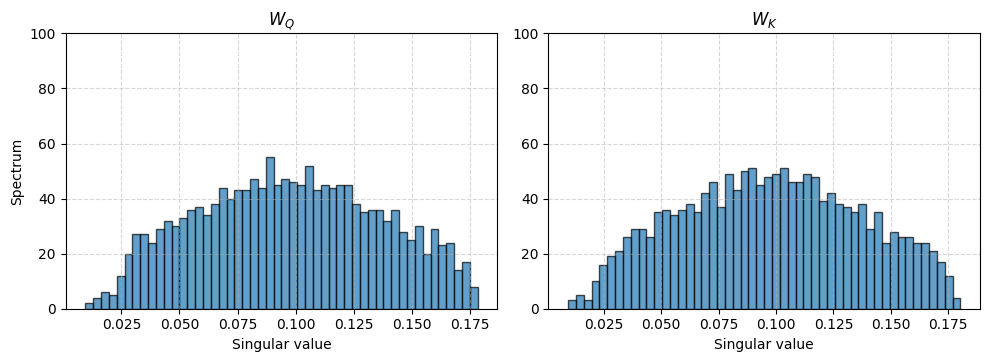


Comparing Q vs K for W_Q_runs_14.pkl


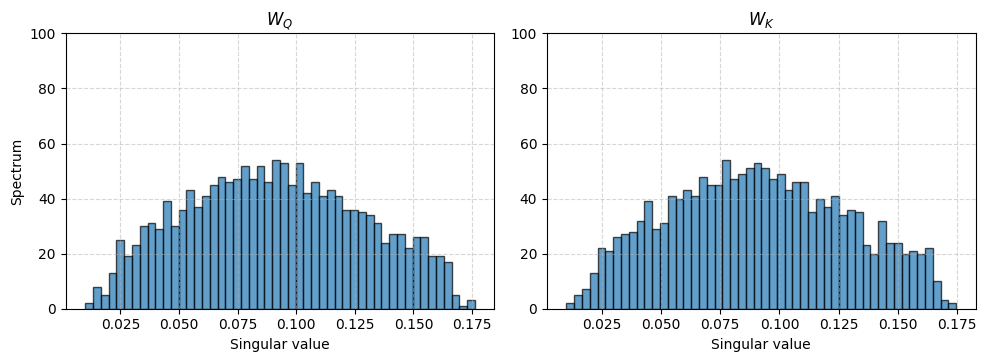


Comparing Q vs K for W_Q_runs_2.pkl


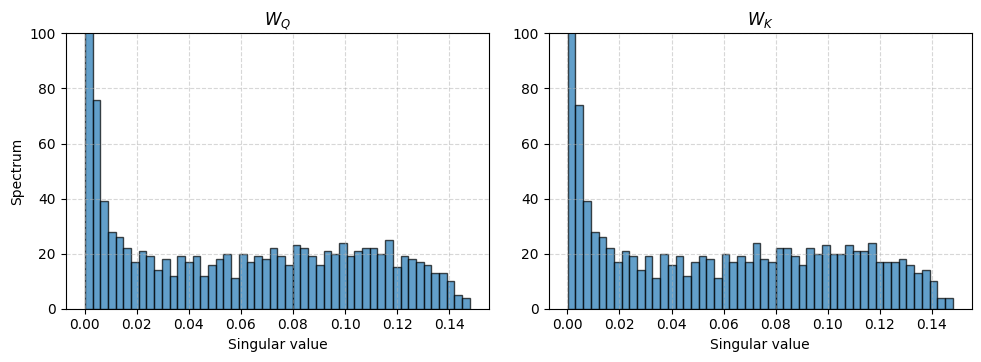


Comparing Q vs K for W_Q_runs_3.pkl


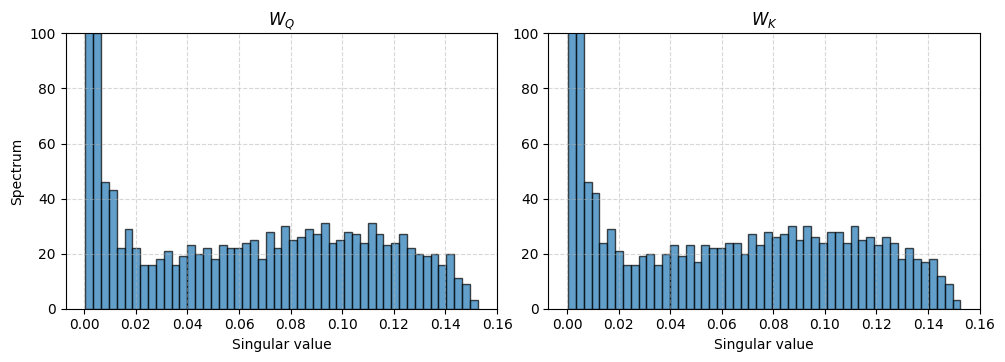


Comparing Q vs K for W_Q_runs_4.pkl


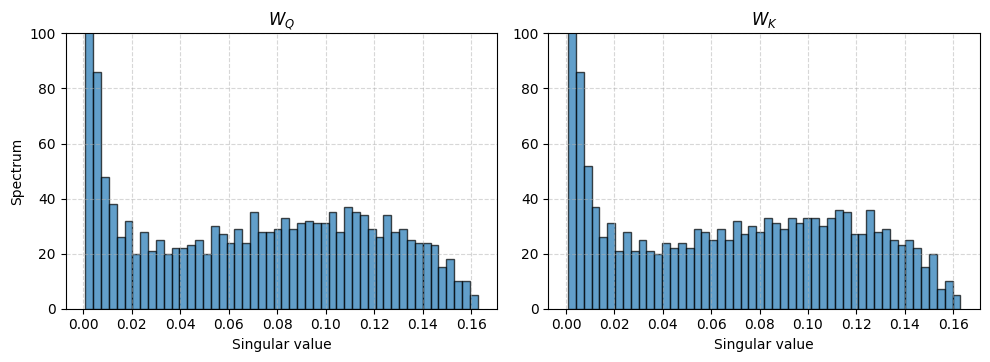


Comparing Q vs K for W_Q_runs_5.pkl


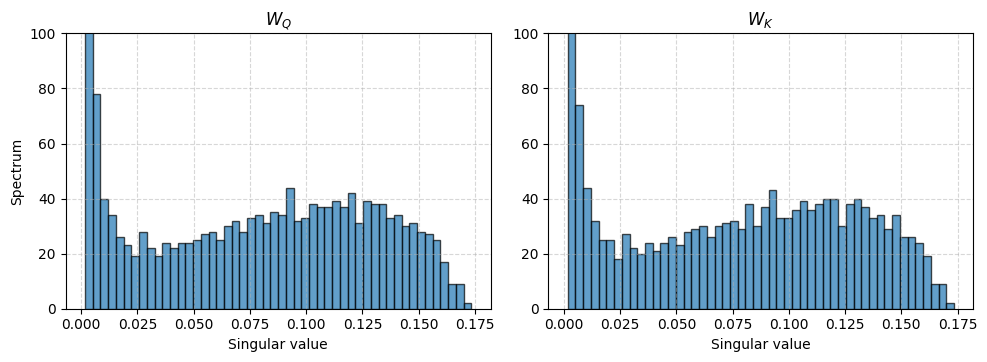


Comparing Q vs K for W_Q_runs_6.pkl


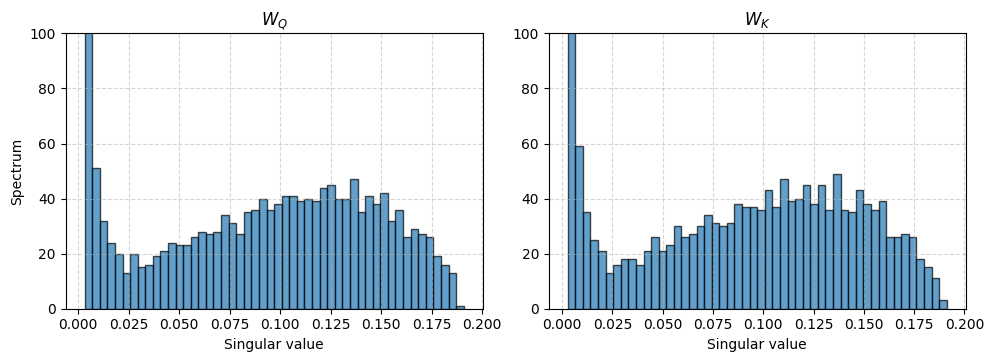

In [4]:
# --- Find pickle files ---
pkl_Q_files = sorted(glob.glob(os.path.join(run_dir, "W_Q_runs_*.pkl")))
pkl_K_files = sorted(glob.glob(os.path.join(run_dir, "W_K_runs_*.pkl")))

print(f"Found {len(pkl_Q_files)} W_Q files and {len(pkl_K_files)} W_K files.")

lambda_index = 4
D = config["D"].iloc[0]
R = config["rho"].iloc[0] * D

# ------------------------------------------------------------
# Compare Q and K for same lambda index, side-by-side (Q | K)
# ------------------------------------------------------------
for q_file, k_file in zip(pkl_Q_files, pkl_K_files):
    print(f"\nComparing Q vs K for {os.path.basename(q_file)}")

    with open(q_file, "rb") as fq, open(k_file, "rb") as fk:
        Q_runs_all = pickle.load(fq)  # list over λ
        K_runs_all = pickle.load(fk)

    num_lambda = min(len(Q_runs_all), len(K_runs_all))

    if lambda_index >= num_lambda:
        print(f"[SKIP] λ={lambda_index} out of range ({num_lambda})")
        continue

    # --- Extract W matrices for the chosen λ ---
    Q_list = Q_runs_all[lambda_index]
    K_list = K_runs_all[lambda_index]

    # --- Collect singular values ---
    sv_Q = np.concatenate([np.linalg.svd(W, compute_uv=False) for W in Q_list])
    sv_K = np.concatenate([np.linalg.svd(W, compute_uv=False) for W in K_list])

    # --- Optional: filter very small singular values ---
    sv_Q = sv_Q[sv_Q > 1e-12]
    sv_K = sv_K[sv_K > 1e-12]

    # --- Plot horizontally ---
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # LEFT: Q
    axes[0].hist(sv_Q/np.sqrt(D * R), bins=50, alpha=0.7, edgecolor="black")
    axes[0].set_title(r"$W_Q$")
    axes[0].set_xlabel("Singular value")
    axes[0].set_ylabel("Spectrum")
    axes[0].set_ylim(0,100)
    axes[0].grid(True, linestyle="--", alpha=0.5)

    # RIGHT: K
    axes[1].hist(sv_K/np.sqrt(D * R), bins=50, alpha=0.7, edgecolor="black")
    axes[1].set_title(r"$W_K$")
    axes[1].set_xlabel("Singular value")
    axes[1].set_ylim(0,100)
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()